In [32]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")
import matplotlib.pyplot as plt
import cv2
import imutils
import numpy as np
from PIL import Image
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
reload_modules(pcd, utils, real, ur5, gripper)

import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, create_image_message, send_message
from magpie_prompts.prompts import sf_grasp_selection
reload_modules(sf_force_thinker, sf_grasp_selection, conversation)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

In [114]:
# # load everything
gripper_log = np.load("scalingforce/gripper_log.npy", allow_pickle=True).item()
robot_log   = np.load("scalingforce/robot_log.npy",   allow_pickle=True).item()
wrist_log   = np.load("scalingforce/wrist_log.npy",   allow_pickle=True).item()
wkspc_log   = np.load("scalingforce/wkspc_log.npy",   allow_pickle=True).item()

gripper_ts   = sorted(gripper_log.keys())
robot_ts   = sorted(robot_log.keys())
wrist_ts = sorted(wrist_log.keys())
wkspc_ts   = sorted(wkspc_log.keys())

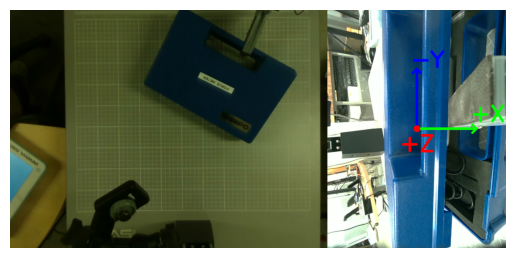

In [115]:
wrist_img_init = wrist_log[wrist_ts[0]]['rgb']
wkspc_img_init = wkspc_log[wkspc_ts[0]]['rgb']

wrist_init_rotated = cv2.rotate(wrist_img_init, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(wrist_init_rotated.copy())
wkspc_init_resized = imutils.resize(wkspc_img_init, height=wrist_init_rotated.shape[0])
init_img = np.hstack((wkspc_init_resized, wrist_img_labeled))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(init_img)

T_wc [[-0.    -1.    -0.     0.013]
 [ 1.     0.     0.     0.011]
 [ 0.     0.     1.    -0.115]
 [ 0.     0.     0.     1.   ]]
T_rc [[-0.893  0.445 -0.059  0.174]
 [ 0.266  0.418 -0.869  0.371]
 [-0.362 -0.792 -0.492 -0.288]
 [ 0.     0.     0.     1.   ]]
R_wc [[-0. -1. -0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
R_rc [[-0.893  0.445 -0.059]
 [ 0.266  0.418 -0.869]
 [-0.362 -0.792 -0.492]]


/tmp/ipykernel_10000/2677836337.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(point_proj[0]), int(point_proj[1])


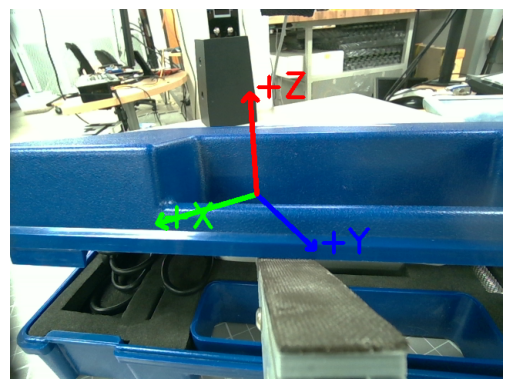

In [160]:
import numpy as np
import cv2
from magpie_control import poses
import spatialmath as sm

import numpy as np
import cv2
def compute_center_3d(intrinsics, image_shape, depth=0.1):
    h, w = image_shape[:2]
    cx = intrinsics[0, 2]
    cy = intrinsics[1, 2]
    fx = intrinsics[0, 0]
    fy = intrinsics[1, 1]

    # Image center pixel coordinates
    u, v = w // 2, h // 2

    # Back-project pixel (u, v) at given depth
    x = (u - cx) * depth / fx
    y = (v - cy) * depth / fy
    z = depth
    return np.array([[x, y, z]], dtype=np.float32).T  # shape (3, 1)

def label_wrist_image(wrist_img, rotation_matrix, camera_intrinsics, axis_length=0.1):
    '''
    Overlays 3D coordinate axes (X, Y, Z) onto an image using the provided rotation matrix
    and camera intrinsics.

    Parameters:
        wrist_img (np.ndarray): The input image.
        rotation_matrix (np.ndarray): A 3x3 rotation matrix.
        camera_intrinsics (np.ndarray): A 3x3 camera intrinsics matrix.
        axis_length (float): Length of the axis vectors in meters or arbitrary units.

    Returns:
        np.ndarray: The labeled image.
    '''
    h, w, _ = wrist_img.shape

    # Define axis colors: X (green), Y (blue), Z (red)
    colors = {
        'x': (0, 255, 0),
        'y': (0, 0, 255),
        'z': (255, 0, 0)
    }

    # Center point in 3D (e.g., origin in camera frame)
    origin_3d = compute_center_3d(camera_intrinsics, wrist_img.shape, depth=0.1)

    # Define axis endpoints in 3D using the rotation matrix
    axes_3d = {
        'x': origin_3d + rotation_matrix @ np.array([[axis_length, 0, 0]]).T,
        'y': origin_3d + rotation_matrix @ np.array([[0, axis_length, 0]]).T,
        'z': origin_3d + rotation_matrix @ np.array([[0, 0, axis_length]]).T,
    }

    # Project 3D points to 2D using the camera intrinsics
    def project(point_3d):
        point_cam = point_3d
        # if point_cam[2] <= 1e-6:
        #     return None  # or (0, 0), or raise an exception
        point_proj = camera_intrinsics @ point_cam
        point_proj /= point_proj[2]
        return int(point_proj[0]), int(point_proj[1])

    center_2d = project(origin_3d)

    for axis, end_3d in axes_3d.items():
        end_2d = project(end_3d)
        cv2.arrowedLine(wrist_img, center_2d, end_2d, colors[axis], 6, tipLength=0.1)
        label_pos = (end_2d[0] + 5, end_2d[1] + 5)
        cv2.putText(wrist_img, f"+{axis.upper()}", label_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.5, colors[axis], 4)

    return wrist_img

T_wc = np.eye(4)
rot = np.array([
    [0, 1, 0],
    [-1,  0, 0],
    [0,  0, 1]
])

t = np.array([
    [-1.15 / 100],
    [ 1.3  / 100],
    [(309.63 - 195.0) / 1000]
])
T_cw = np.eye(4)
T_cw[:3, :3] = rot
T_cw[:3, 3] = t.flatten()
T_wc = np.linalg.inv(T_cw)
R_wc = T_wc[:3, :3]
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[0]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
T_rw = np.linalg.inv(T_wr)
T_rc = T_wc @ T_rw
R_rc = T_rc[:3, :3]
print("T_wc", T_wc)
print("T_rc", T_rc)
print("R_wc", R_wc)
print("R_rc", R_rc)
R_i = np.eye(3)

intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
# img_labeled = label_wrist_image(wrist_img_init.copy(), R_wc, intrinsics, axis_length=0.03)
img_labeled = label_wrist_image(wrist_img_init.copy(), R_rc, intrinsics, axis_length=0.03)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(img_labeled)

In [42]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
    # model = "gpt-4o-mini"
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.fromarray(init_img).convert("RGB")
# img = Image.fromarray(wrist_img_labeled).convert("RGB")

prompt_config = {
"obj": "blue case top handle",
"task": "open the blue case"
}

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = create_image_message(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
# np.save("scalingforce/motion_plan.npy", motion_plan, allow_pickle=True)
motion_plan

{'position_direction': [1, -1, 0],
 'position_goal': [0.1, 0.02, 0.0],
 'force': [3.0, 1.0, 0.0],
 'grasp_force': 7.5,
 'duration': 2.0}

In [43]:
print(response)

[start of motion plan]
The task is to open the blue case while grasping the blue case top handle.

Aligning Image With Motion:
The provided image confirms the presence of a blue case with a handle, situated on a surface. The task involves grasping the handle and opening the case.
The green axis pointing to the right of the image is the positive X-axis, corresponding to the direction the case needs to swing to open.
The blue axis pointing up the image is the negative Y-axis, corresponding to upward lift that may be required to free the case from latch friction.
The red dot pointing into the image is the positive Z-axis, corresponding to potentially no motion directly along the Z axis, but force may be required to maintain contact.

Position Motion Required:
X-axis: Movement is required in the positive X-axis to swing the case open.

Y-axis: Movement is required in the negative Y-axis to lift the case slightly.

Z-axis: No motion required.

To estimate the forces required to accomplish o

In [1]:
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
motion_plan

goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(direction < 0, -1, 1)
force = np.array(motion_plan['force']) * sign
wrench_goal = np.hstack((force, np.zeros(3)))
init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 5
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005


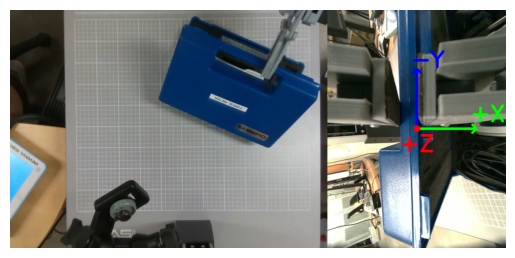

In [89]:
wrist_img_final = wrist_log[wrist_ts[-1]]['rgb']
wkspc_img_final = wkspc_log[wkspc_ts[-1]]['rgb']

wrist_final_rotated = cv2.rotate(wrist_img_final, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(wrist_final_rotated.copy())
wkspc_final_resized = imutils.resize(wkspc_img_final, height=wrist_final_rotated.shape[0])
# final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))
# final_img = np.hstack((img_wkspc_resized, wrist_img2_labeled))
final_img = np.hstack((wkspc_final_resized, wrist_img_labeled))
# cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [103]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
# motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled along wrist [x, y, z] axes: {dist_wrist}\n"
motion_report += f"Distance traveled along robot [x, y, z] axes: {dist[:3]}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    return summary
desired_freq = 2
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench (x, y, z, rx, ry, rz)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

for i in gripper_log: gripper_log[i]['cf'] *= 2
gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf", "Gripper Contact Force (x, y, z)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)

Motion Plan Results: 
Distance traveled along wrist [x, y, z] axes: [-0.072  0.048 -0.003]
Distance traveled along robot [x, y, z] axes: [ 0.025 -0.049  0.067]

6D Wrench (x, y, z, rx, ry, rz) Log Summary:
Motion Duration: 2.9850471019744873s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [ 0.14 -0.21 -1.36  0.02  0.05 -0.  ]
0.5s to 1.0: [-0.03 -0.66 -1.16  0.07  0.02  0.01]
1.0s to 1.5: [ 0.43 -2.2   0.93  0.26  0.07  0.05]
1.5s to 2.0: [ 1.07 -2.29  1.1   0.29  0.19  0.06]
2.0s to 2.5: [ 1.58 -2.19  1.43  0.27  0.24  0.02]
2.5s to 3.0: [ 2.   -1.7   1.5   0.23  0.29 -0.03]

Gripper Contact Force (x, y, z) Log Summary:
Motion Duration: 2.9574172496795654s
Average cf Downsampled at 2Hz:
0.0s to 0.5: 132.46
0.5s to 1.0: 23.89
1.0s to 1.5: 644.92
1.5s to 2.0: 943.45
2.0s to 2.5: 957.57
2.5s to 3.0: 948.21



In [96]:
print(motion_report)

Initial Motion Plan: {'position_direction': [1, -1, 0], 'position_goal': [0.1, 0.02, 0.0], 'force': [3.0, 1.0, 0.0], 'grasp_force': 7.5, 'duration': 2.0}

Motion Plan Results: 
Distance traveled along wrist [x, y, z] axes: [-0.072  0.048 -0.003]
6D Wrench (x, y, z, rx, ry, rz) Log Summary:
Motion Duration: 2.9850471019744873s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [ 0.14 -0.21 -1.36  0.02  0.05 -0.  ]
0.5s to 1.0: [-0.03 -0.66 -1.16  0.07  0.02  0.01]
1.0s to 1.5: [ 0.43 -2.2   0.93  0.26  0.07  0.05]
1.5s to 2.0: [ 1.07 -2.29  1.1   0.29  0.19  0.06]
2.0s to 2.5: [ 1.58 -2.19  1.43  0.27  0.24  0.02]
2.5s to 3.0: [ 2.   -1.7   1.5   0.23  0.29 -0.03]
Gripper Contact Force (x, y, z) Log Summary:
Motion Duration: 2.9574172496795654s
Average cf Downsampled at 2Hz:
0.0s to 0.5: 1.03
0.5s to 1.0: 0.19
1.0s to 1.5: 5.04
1.5s to 2.0: 7.37
2.0s to 2.5: 7.48
2.5s to 3.0: 7.41
